In [3]:
import pandas as pd
from sklearn.datasets import load_diabetes

# Load data
diabetes = load_diabetes()

df=pd.DataFrame(diabetes.data,columns=diabetes.feature_names)

df["target"] = diabetes.target

# See top 5 rows
print(df.head())

# Summary
print(df.describe())


        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-0

**Visualize the Distributions (How Each Feature Looks)**

We’ll use histograms and boxplots.

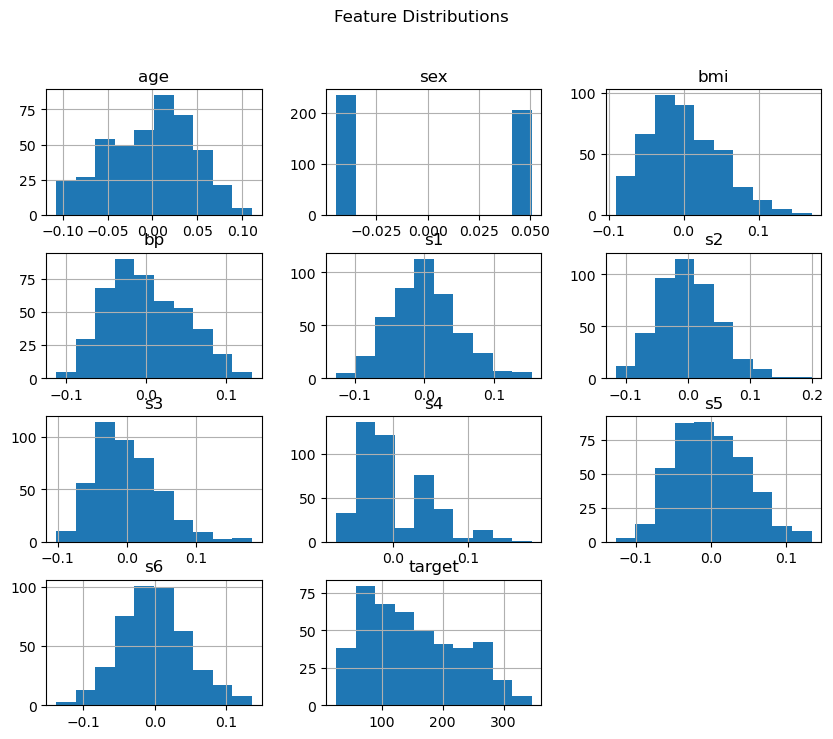

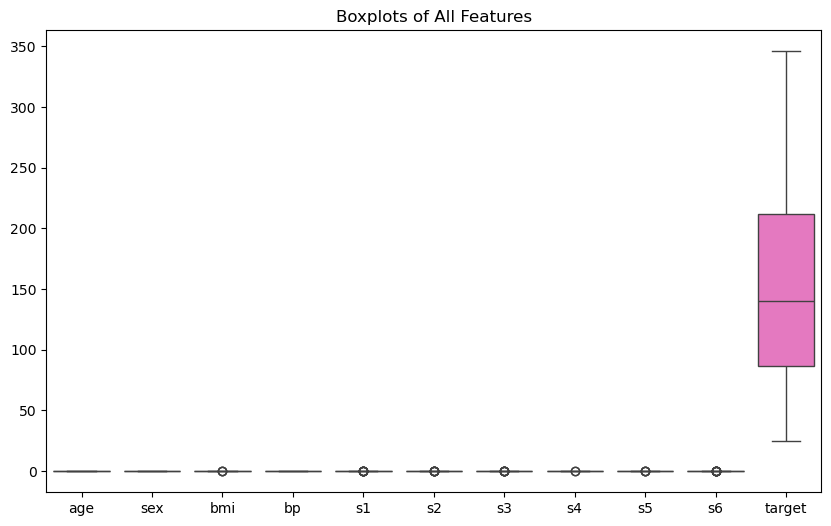

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

# Or for clearer look at outliers:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplots of All Features")
plt.show()


Check Relationship Between Each Feature and Target

This is the most important part for deciding your algorithm.

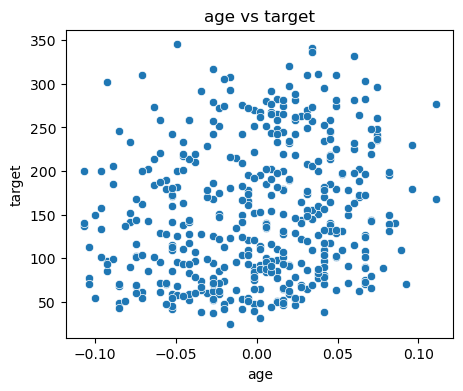

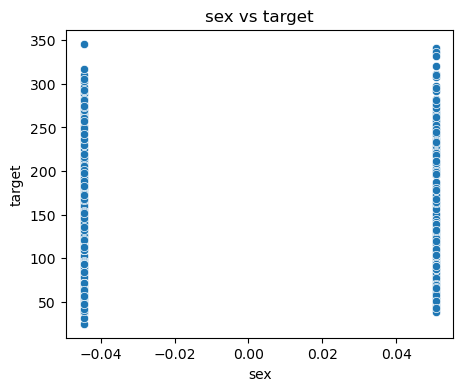

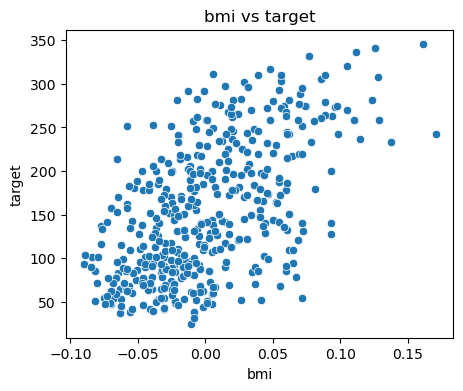

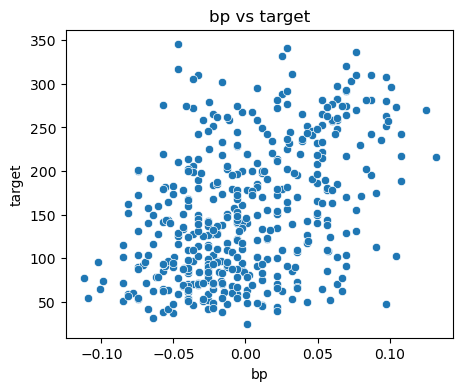

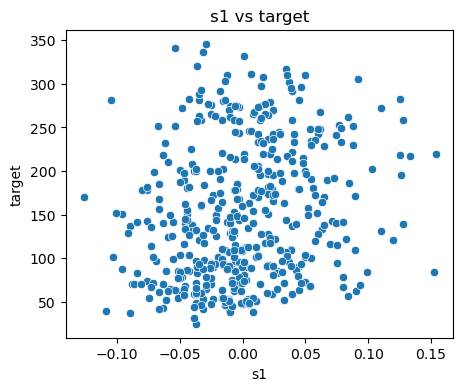

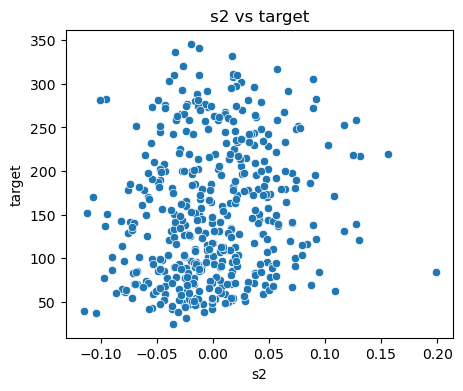

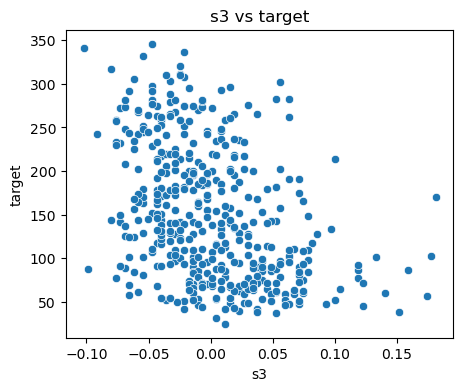

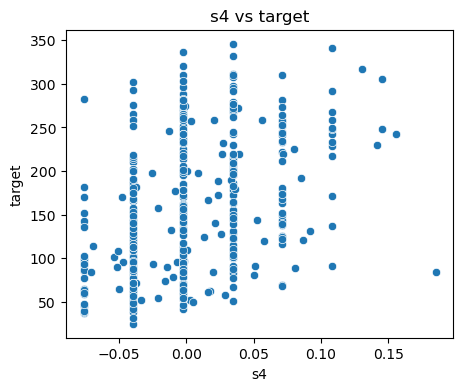

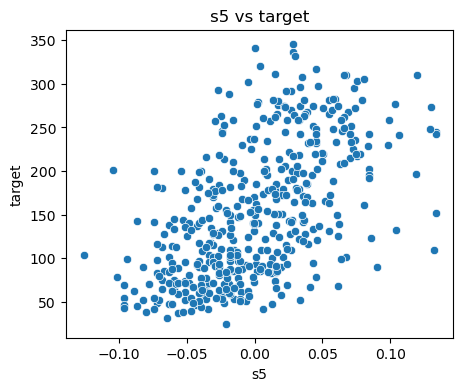

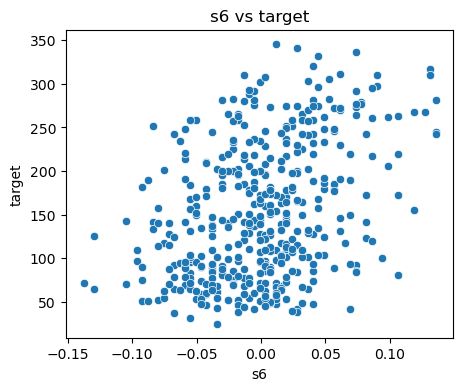

In [6]:
for col in df.columns[:-1]:  # skip target
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[col], y=df["target"])
    plt.title(f"{col} vs target")
    plt.show()


STEP 5: Correlation Heatmap

This shows how strongly each feature is related to the target.

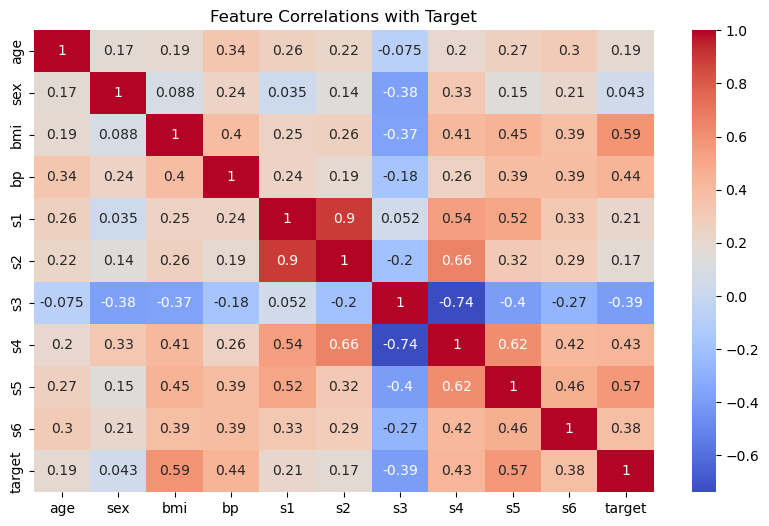

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlations with Target")
plt.show()

Let’s recall your current Linear Regression results (R² ≈ 0.44).
That’s decent but not great — meaning:

The model explains 44% of the variation, but 56% is still unexplained.

So maybe:

The relationship between predictors and target isn’t perfectly linear.

We need to add flexibility — that’s where Polynomial Regression comes in.

# Implementing Polynomial Regression

In [23]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split



In [24]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
x=df.drop('target',axis=1)
y=df['target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) #random_states= 42 means you are telling your machine to start shuffel from no 42
x_train_scale= scale.fit_transform(x_train)
x_test_scale=scale.fit_transform(x_test)

In [26]:
# Create polynomial features (degree=2 means square terms)
poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_poly = poly.fit_transform(x_train_scale)
x_test_poly = poly.fit_transform(x_test_scale)

# This allows the model to detect curves and interactions between features.

In [27]:
poly_reg = LinearRegression()
poly_reg.fit(x_train_poly, y_train)


LinearRegression()

# Predict and Evaluate**

In [28]:
y_pred_poly = poly_reg.predict(x_test_poly)

mse = mean_squared_error(y_test, y_pred_poly)
mae = mean_absolute_error(y_test, y_pred_poly)
r2 = r2_score(y_test, y_pred_poly)

print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)


MSE: 2.4493002364118665e+23
MAE: 493370920359.1272
R²: -4.622933341042245e+19


**These result numbers are huge (and R² is negative).
That tells us the model is completely failing — it’s not overfitting, it’s blowing up numerically.**

# Regularize the polyynomial model

In [29]:
from sklearn.linear_model import Ridge

ridge_poly = Ridge(alpha=1.0)
ridge_poly.fit(x_train_poly, y_train)
y_pred_poly = ridge_poly.predict(x_test_poly)

mse = mean_squared_error(y_test, y_pred_poly)
mae = mean_absolute_error(y_test, y_pred_poly)
r2 = r2_score(y_test, y_pred_poly)

print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)


MSE: 3248.9396722875854
MAE: 43.47427806211145
R²: 0.3867786680143246
